## TEXT CLASSIFICATION AND SENTIMENT ANALYSIS

#### Data Cleaning

In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

df = pd.read_csv("amazonreviews.tsv", sep="\t")

print(df.head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...


In [2]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (10000, 2)


In [3]:
print(df.isnull().sum())

df = df.dropna(subset=["review"])

print(df.isnull().sum())

label     0
review    0
dtype: int64
label     0
review    0
dtype: int64


In [4]:
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)

    words = [word for word in text.split() if word not in stop_words]

    return " ".join(words)

df["review"] = df["review"].apply(preprocess_text)

print(df[["label", "review"]].head())

  label                                             review
0   pos  stuning even nongamer sound track beautiful pa...
1   pos  best soundtrack ever anything im reading lot r...
2   pos  amazing soundtrack favorite music time hands i...
3   pos  excellent soundtrack truly like soundtrack enj...
4   pos  remember pull jaw floor hearing youve played g...


In [5]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB
None
  label                                             review
0   pos  stuning even nongamer sound track beautiful pa...
1   pos  best soundtrack ever anything im reading lot r...
2   pos  amazing soundtrack favorite music time hands i...
3   pos  excellent soundtrack truly like soundtrack enj...
4   pos  remember pull jaw floor hearing youve played g...


#### Exploratory Analysis

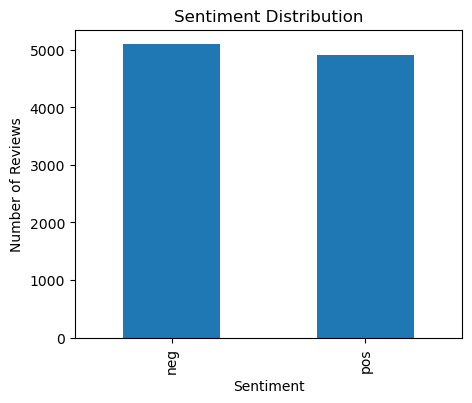

In [6]:
import matplotlib.pyplot as plt

sentiment_counts = df["label"].value_counts()

plt.figure(figsize=(5,4))
sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

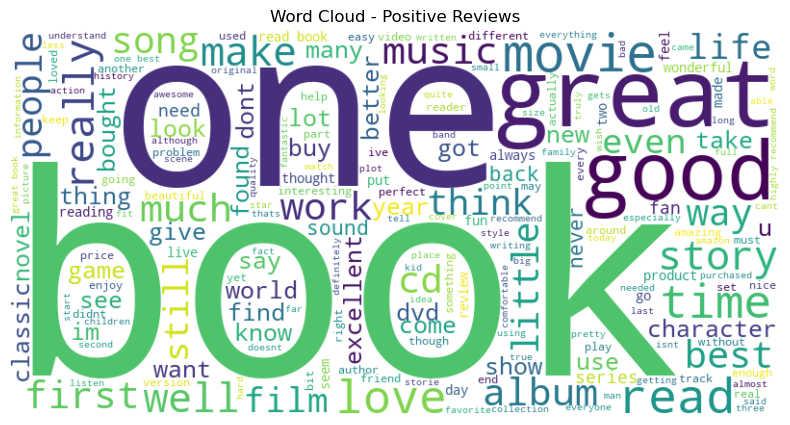

In [7]:
from wordcloud import WordCloud

positive_text = " ".join(df[df["label"] == "pos"]["review"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Positive Reviews")
plt.show()

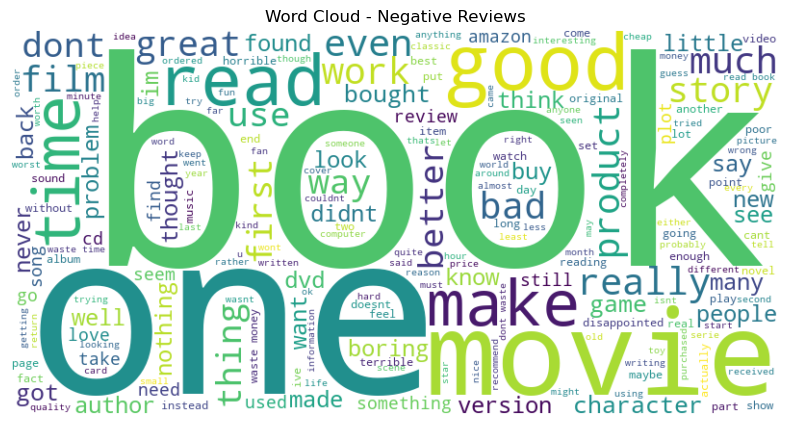

In [9]:
negative_text = " ".join(df[df["label"] == "neg"]["review"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Negative Reviews")
plt.show()

In [10]:
from collections import Counter

positive_words = positive_text.split()

positive_counts = Counter(positive_words)

print("Top 20 Positive Words:")
print(positive_counts.most_common(20))

Top 20 Positive Words:
[('book', 3313), ('great', 2087), ('one', 1835), ('good', 1635), ('read', 1553), ('like', 1268), ('movie', 1085), ('would', 943), ('love', 902), ('time', 871), ('well', 854), ('really', 827), ('best', 801), ('get', 793), ('story', 713), ('first', 708), ('much', 650), ('cd', 581), ('music', 559), ('also', 557)]


In [11]:
negative_words = negative_text.split()

negative_counts = Counter(negative_words)

print("Top 20 Negative Words:")
print(negative_counts.most_common(20))

Top 20 Negative Words:
[('book', 3184), ('one', 2022), ('like', 1547), ('movie', 1465), ('would', 1438), ('dont', 1240), ('read', 1187), ('get', 1139), ('good', 1134), ('time', 1034), ('even', 898), ('buy', 814), ('really', 778), ('much', 769), ('bad', 749), ('money', 744), ('first', 736), ('could', 658), ('better', 656), ('great', 632)]


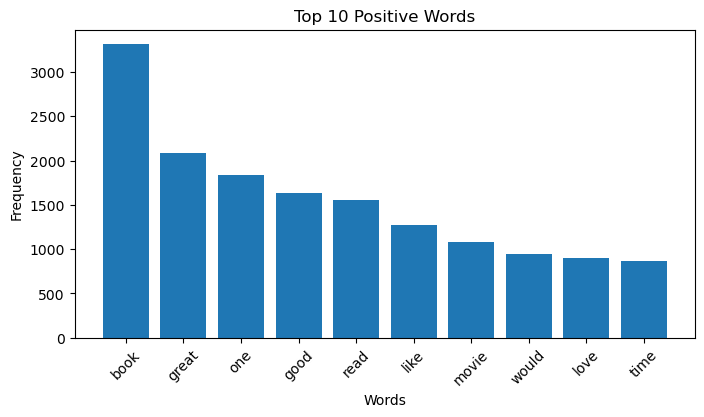

In [12]:
top_positive = positive_counts.most_common(10)

words = [word for word, count in top_positive]
counts = [count for word, count in top_positive]

plt.figure(figsize=(8,4))
plt.bar(words, counts)
plt.title("Top 10 Positive Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

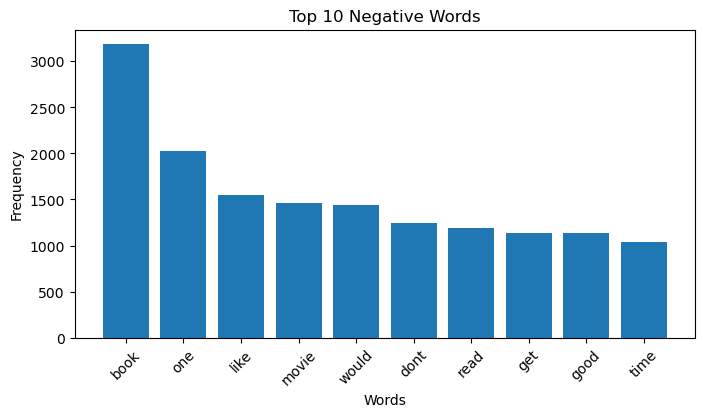

In [13]:
top_negative = negative_counts.most_common(10)

words = [word for word, count in top_negative]
counts = [count for word, count in top_negative]

plt.figure(figsize=(8,4))
plt.bar(words, counts)
plt.title("Top 10 Negative Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

#### Model Development

In [14]:
X = df["review"]
y = df["label"]

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(X)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
y_pred = lr_model.predict(X_test)

In [19]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

#### Validation

In [20]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

f1 = f1_score(y_test, y_pred, pos_label="pos")
print("F1-Score:", f1)

Accuracy: 0.845
F1-Score: 0.8400412796697626


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         neg       0.85      0.84      0.85      1037
         pos       0.83      0.85      0.84       963

    accuracy                           0.84      2000
   macro avg       0.84      0.85      0.84      2000
weighted avg       0.85      0.84      0.85      2000



In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[876 161]
 [149 814]]


In [23]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr_model, X_tfidf, y, cv=5, scoring="accuracy")

print("Cross-Validation Scores:", cv_scores)
print("Average Cross-Validation Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.8595 0.8335 0.828  0.831  0.849 ]
Average Cross-Validation Accuracy: 0.8402


In [24]:
print("Model Validation Results")
print("------------------------")
print("Test Accuracy:", accuracy)
print("F1-Score:", f1)
print("Average Cross-Validation Accuracy:", cv_scores.mean())

Model Validation Results
------------------------
Test Accuracy: 0.845
F1-Score: 0.8400412796697626
Average Cross-Validation Accuracy: 0.8402
